In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import datasets, model_selection, linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score
from datetime import datetime

**Feature variables** are the columns like here in the diabetes dataset we take the BMI, sex, bp, age etc as features.

**Features** are the input variables and **labels** are the output.

In [57]:
X,y=datasets.load_diabetes(return_X_y=True)
X_bmi = X[:,2].reshape(-1,1)
print(X.shape)
print(X[0])

(442, 10)
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


X is our features and y is our label.
We use `train_test_split` to split the dataset into 2 parts randomly into the

 **Training set**-> Used to train the model
 **Testing set**-> Used to evaluate how well the model performs

`test_size=` is the amount of data used for testing here we use 33% of the data.


If we don't split the data then the model will just memorize the dataset and it will give us a 100% accuracy which looks good but is incorrect it is called **Overfitting** it will fail with new data.

By splitting the model we can see how the model generalizes to unseen data.


**StandardScaler** is used to scale the values in the dataset to keep the data in a consistent and similar range. For instance, in the diabetes case if we compare blood pressure to BMI, because blood pressure is a larger numeric value than BMI the model thinks that blood pressure matters more which is incorrect. This is called math bias where the larger number is given preference.

The data is scaled in the form of a z-score where the mean of the data roughly tends to 0 and the standard deviation tends to 1 making the data normalized. 
When the data is normalized the values can be compared relative to each other using the mean and standard deviation. 


Scaling must be learnt from the training set only because the model must learn what it is to have "normal" data. If we scale from the testing data then it would be cheating because the new data would influence the scaling learned during training.

We must always scale after the splitting of the model because if we don't then the future data or the test data will also be scaled and that will be considered to be normal which will give biased results causing better results but incorrect ones. This is called **data leakage** the model already gets to know the future data which gives biased results. 

In [58]:
X_train,X_test,y_train,y_test=model_selection.train_test_split(X_bmi,y,test_size=0.33)

bmi_mean=X_train.mean()
bmi_std=X_train.std()

def user_input_scale(user_bmi):
    real_min, real_max = 21, 35       # approximate real-world BMI range
    scaled_min, scaled_max = -0.1, 0.1  # approximate scaled range in dataset
    scaled = (user_bmi - real_min) / ( - real_min) * (scaled_max - scaled_min) + scaled_min
    return scaled


In [59]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train) # we fit scaler only on training data
X_test_scaled=scaler.transform(X_test)

In [60]:
model=linear_model.LinearRegression()
model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_pred = model.predict(X_test_scaled)

**Mean Squared Error** is the average squared difference between predicted and actual diabetes dataset. **RMSE(Root Mean Squared Error)** should be used to compare. The rule of thumb is RMSE ≪ target range. Here in this dataset y ranges from 25 to 350 and the **spread(y_max-y_min)** is approximately 300.




**r^2 score** measures how well a linear regression model predicts actual data, with values ranging from 0 to 1.

In [ ]:
# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error on test set: {mse:.2f}")
print(f"R^2 score on test set: {r2:.2f}")

for i in range(5): # first 5 samples from test set
    print(f"Predicted: {y_pred[i]:.2f}, Actual: {y_test[i]}")

Mean squared error on test set: 3767.74
R^2 score on test set: 0.33
Predicted: 199.58, Actual: 317.0
Predicted: 150.78, Actual: 139.0
Predicted: 197.50, Actual: 272.0
Predicted: 173.62, Actual: 197.0
Predicted: 154.93, Actual: 196.0


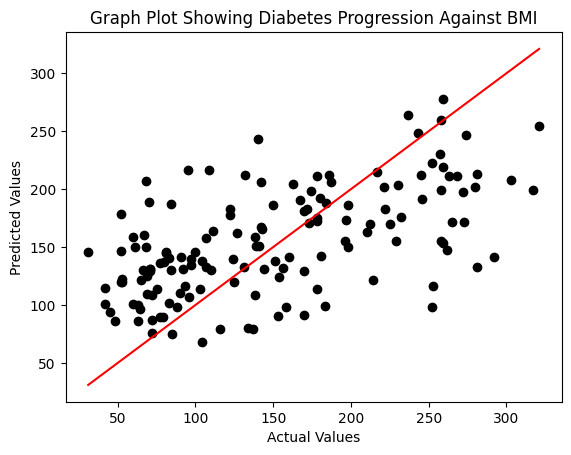

In [63]:
plt.scatter(y_test, y_pred, color='black')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Graph Plot Showing Diabetes Progression Against BMI')
plt.show()